In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



<class 'pandas.DataFrame'>
Index: 237 entries, 2023-01-03 to 2023-12-29
Data columns (total 90 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AAPL           237 non-null    float64
 1   ABBV           237 non-null    float64
 2   ABT            237 non-null    float64
 3   ADBE           237 non-null    float64
 4   AMD            237 non-null    float64
 5   AMGN           237 non-null    float64
 6   AMZN           237 non-null    float64
 7   AXISBANK.NS    237 non-null    float64
 8   AXP            237 non-null    float64
 9   BAC            237 non-null    float64
 10  BAJAJ-AUTO.NS  237 non-null    float64
 11  BAJFINANCE.NS  237 non-null    float64
 12  BLK            237 non-null    float64
 13  BMY            237 non-null    float64
 14  BP             237 non-null    float64
 15  BPCL.NS        237 non-null    float64
 16  BRITANNIA.NS   237 non-null    float64
 17  C              237 non-null    float64
 18  CMCSA     

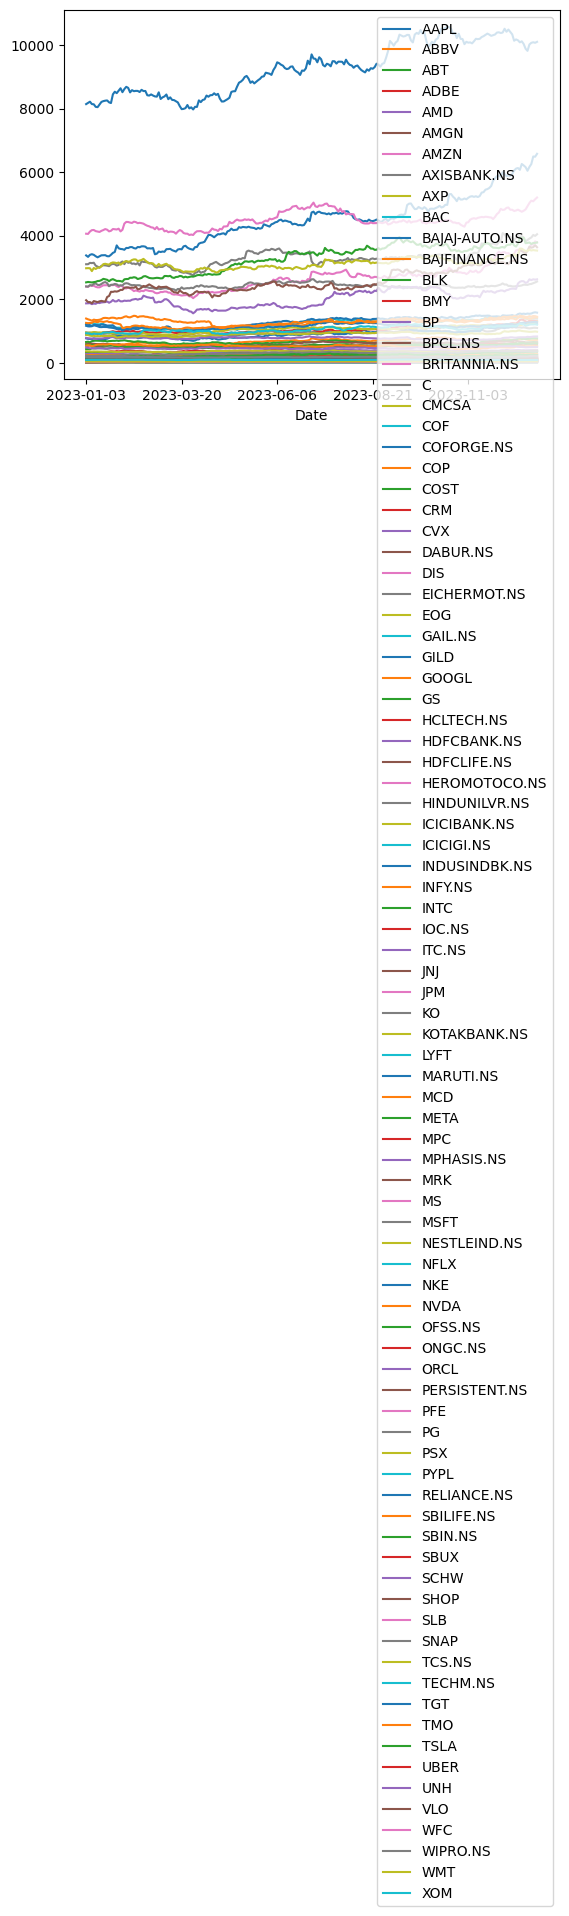

In [2]:
data = pd.read_csv('../DATA/stocks_100.csv', index_col='Date')
data.head()
data.info()
data.describe()
data.plot()
plt.show()  

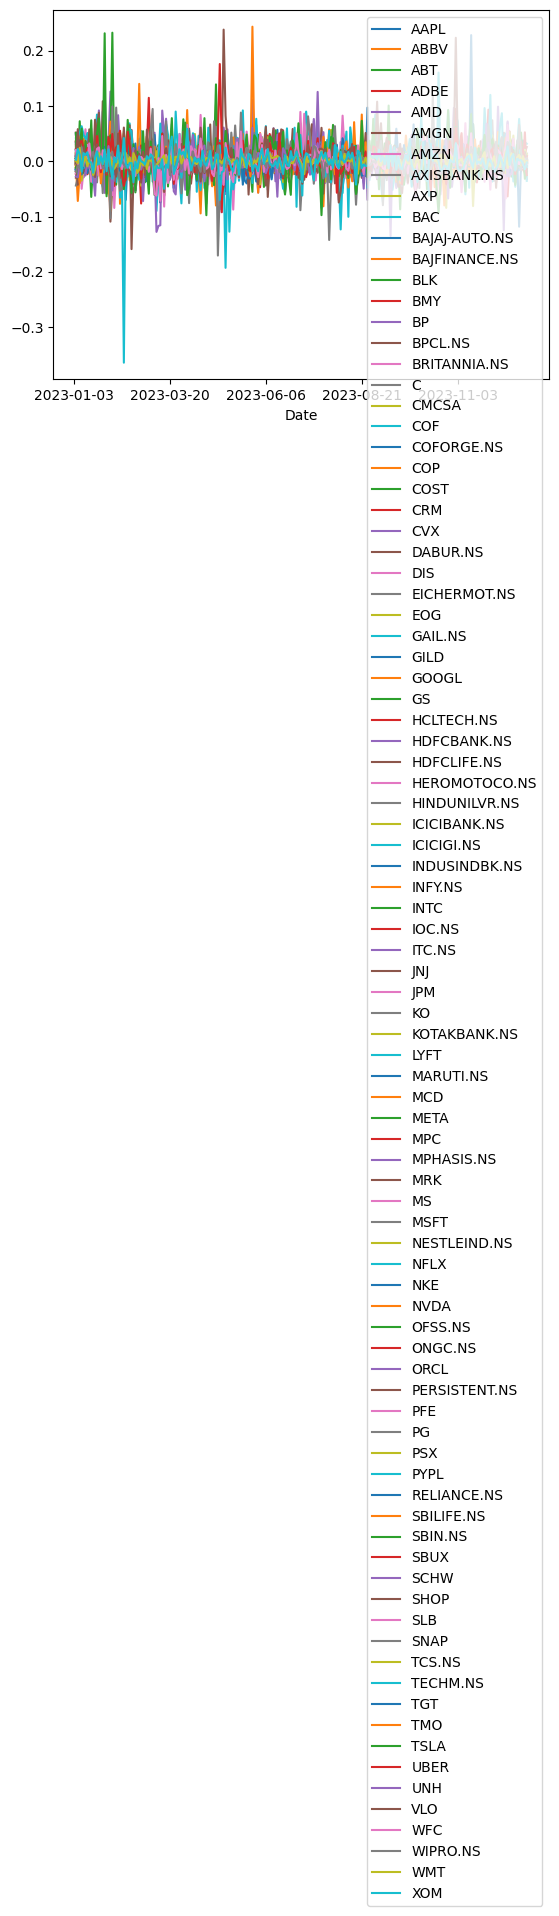

In [3]:
daily_returns = data.pct_change()
daily_returns.head()
daily_returns.plot()
plt.show()

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(daily_returns.dropna())

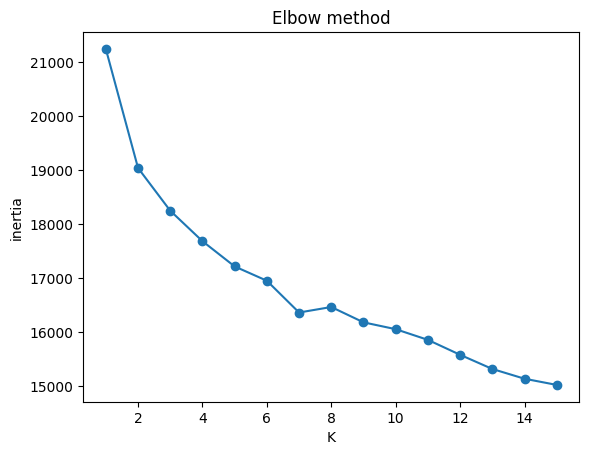

In [5]:
    
from sklearn.cluster import KMeans


inertia = []
for k in range(1, 16):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    inertia.append(model.inertia_)

plt.plot(range(1, 16), inertia, marker='o')
plt.xlabel('K')
plt.ylabel('inertia')
plt.title('Elbow method')
plt.show()

In [ ]:
returns_clean = daily_returns.dropna()
X_stocks = returns_clean.T  # 90 stocks × 236 days

scaler = StandardScaler()
X_scaled_stocks = scaler.fit_transform(X_stocks)

model = KMeans(n_clusters=7, random_state=42)
model.fit(X_scaled_stocks)
labels = model.labels_


for cluster in range(7):
    stocks = X_stocks.index[labels == cluster].tolist()
    print(f"\nCluster {cluster}: {stocks}")



Cluster 0: ['AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BRITANNIA.NS', 'COFORGE.NS', 'DABUR.NS', 'EICHERMOT.NS', 'GAIL.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS', 'HEROMOTOCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'ICICIGI.NS', 'INDUSINDBK.NS', 'INFY.NS', 'IOC.NS', 'ITC.NS', 'KOTAKBANK.NS', 'MARUTI.NS', 'MPHASIS.NS', 'NESTLEIND.NS', 'OFSS.NS', 'ONGC.NS', 'PERSISTENT.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SBIN.NS', 'TCS.NS', 'TECHM.NS', 'WIPRO.NS']

Cluster 1: ['AAPL', 'ADBE', 'AMD', 'AMZN', 'GOOGL', 'INTC', 'META', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'SNAP', 'TSLA', 'UBER']

Cluster 2: ['ABBV', 'AMGN', 'BMY', 'GILD', 'JNJ', 'MRK', 'PFE', 'UNH']

Cluster 3: ['PYPL', 'SHOP']

Cluster 4: ['AXP', 'BAC', 'BP', 'C', 'COF', 'COP', 'CVX', 'EOG', 'GS', 'JPM', 'MPC', 'MS', 'PSX', 'SCHW', 'SLB', 'VLO', 'WFC', 'XOM']

Cluster 5: ['ABT', 'BLK', 'BPCL.NS', 'CMCSA', 'COST', 'CRM', 'DIS', 'KO', 'MCD', 'NKE', 'PG', 'SBUX', 'TGT', 'TMO', 'WMT']

Cluster 6: ['LYFT']


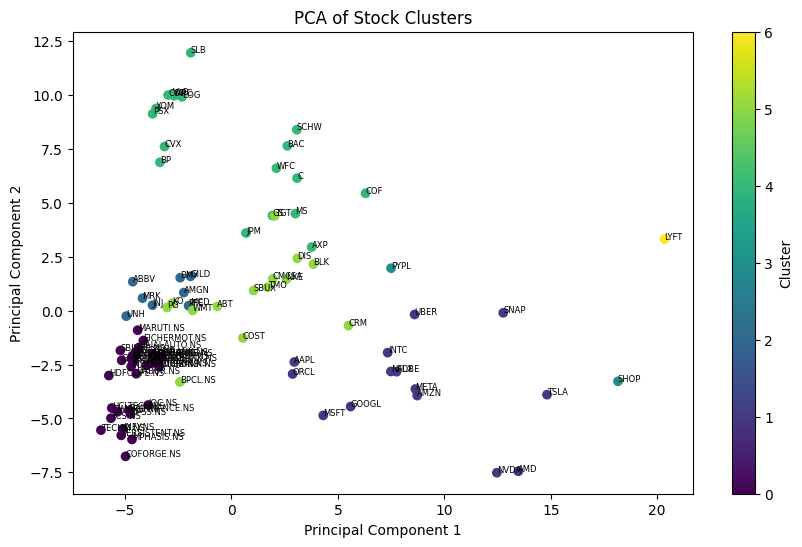

In [26]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_stocks)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Stock Clusters')
for i, stock in enumerate(X_stocks.index):
    plt.annotate(stock, (X_pca[i, 0], X_pca[i, 1]), fontsize=6)
plt.colorbar(scatter, label='Cluster')
plt.show()  


portfolio builder


In [16]:
import random

for cluster in range(7):
    stocks = X_stocks.index[labels == cluster].tolist()
    if len(stocks) > 0:
        selected_stock = random.choice(stocks)
        print(f"\nCluster {cluster}: {selected_stock}")


Cluster 0: ONGC.NS

Cluster 1: AAPL

Cluster 2: JNJ

Cluster 3: SHOP

Cluster 4: SCHW

Cluster 5: CRM

Cluster 6: LYFT


Stock Risk Detector.

In [20]:
clusters = {}
for cluster in range(7):
    stocks = X_stocks.index[labels == cluster].tolist()
    clusters[cluster] = stocks

for cluster, stocks in clusters.items():
    risk = 1 / len(stocks)
    print(f"\nCluster {cluster}: {stocks} (Risk: {risk:.2f})")


Cluster 0: ['AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BRITANNIA.NS', 'COFORGE.NS', 'DABUR.NS', 'EICHERMOT.NS', 'GAIL.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS', 'HEROMOTOCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'ICICIGI.NS', 'INDUSINDBK.NS', 'INFY.NS', 'IOC.NS', 'ITC.NS', 'KOTAKBANK.NS', 'MARUTI.NS', 'MPHASIS.NS', 'NESTLEIND.NS', 'OFSS.NS', 'ONGC.NS', 'PERSISTENT.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SBIN.NS', 'TCS.NS', 'TECHM.NS', 'WIPRO.NS'] (Risk: 0.03)

Cluster 1: ['AAPL', 'ADBE', 'AMD', 'AMZN', 'GOOGL', 'INTC', 'META', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'SNAP', 'TSLA', 'UBER'] (Risk: 0.07)

Cluster 2: ['ABBV', 'AMGN', 'BMY', 'GILD', 'JNJ', 'MRK', 'PFE', 'UNH'] (Risk: 0.12)

Cluster 3: ['PYPL', 'SHOP'] (Risk: 0.50)

Cluster 4: ['AXP', 'BAC', 'BP', 'C', 'COF', 'COP', 'CVX', 'EOG', 'GS', 'JPM', 'MPC', 'MS', 'PSX', 'SCHW', 'SLB', 'VLO', 'WFC', 'XOM'] (Risk: 0.06)

Cluster 5: ['ABT', 'BLK', 'BPCL.NS', 'CMCSA', 'COST', 'CRM', 'DIS', 'KO', 'MCD', 'NKE', 'PG', 'SBUX', 'TGT', 'TMO'

 Market Crash Analyser.

In [23]:
stock_input = input("Enter stock name (e.g. TSLA): ").strip().upper()

crash_cluster = None
for stock, label in zip(X_stocks.index, labels):
    if stock == stock_input:
        crash_cluster = label
        break

if crash_cluster is not None:
    crash_stocks = X_stocks.index[labels == crash_cluster].tolist()
    crash_stocks = [s for s in crash_stocks if s != stock_input]
    print(f"\n⚠️ If {stock_input} crashes, these stocks are at risk:")
    print(crash_stocks)
else:
    print("Stock not found!")


⚠️ If AMD crashes, these stocks are at risk:
['AAPL', 'ADBE', 'AMZN', 'GOOGL', 'INTC', 'META', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'SNAP', 'TSLA', 'UBER']


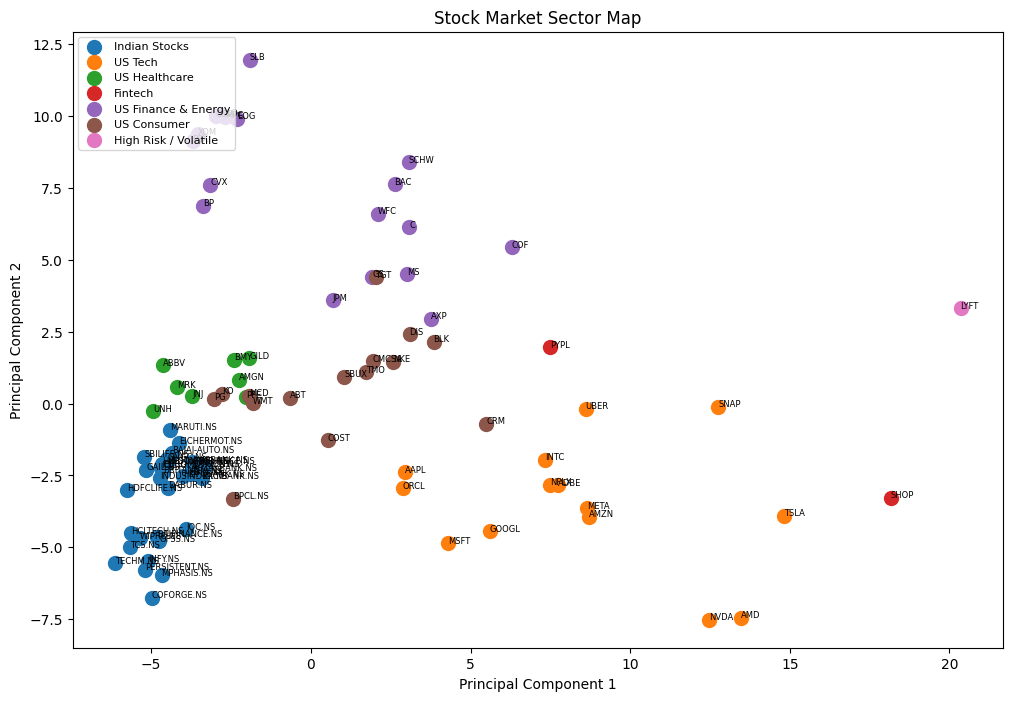

In [28]:
cluster_names = {
    0: 'Indian Stocks',
    1: 'US Tech',
    2: 'US Healthcare',
    3: 'Fintech',
    4: 'US Finance & Energy',
    5: 'US Consumer',
    6: 'High Risk / Volatile'
}


plt.figure(figsize=(12, 8))

for cluster in range(7):
    mask = labels == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cluster_names[cluster], s=100)

for i, stock in enumerate(X_stocks.index):
    plt.annotate(stock, (X_pca[i, 0], X_pca[i, 1]), fontsize=6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Stock Market Sector Map')
plt.legend(loc='upper left', fontsize=8)
plt.show()